In [46]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import os

plt.rcParams.update({'font.family': 'Times New Roman', 'mathtext.fontset': 'cm'})

In [47]:
def normalize(data, background):
    wl, abs_data = data['Wavelength (nm)'], data['Absorbance']
    abs_background = background['Absorbance']
    abs_data = abs_data - abs_background
    abs_data = (abs_data - np.min(abs_data)) / (np.max(abs_data) - np.min(abs_data))
    return wl, abs_data

In [66]:
dirname = './Abs'
listdir = os.listdir(dirname)

background = pd.read_csv(os.path.join(dirname, 'background.csv'), skiprows=200, names=['Wavelength (nm)', 'Absorbance'])
background2 = pd.read_csv(os.path.join(dirname, 'background2.csv'), skiprows=200, names=['Wavelength (nm)', 'Absorbance'])
abs_dict = dict()

for file in listdir:
    if not '.csv' in file or 'background' in file:
        continue
    data = pd.read_csv(os.path.join(dirname, file), skiprows=200, names=['Wavelength (nm)', 'Absorbance'])

    if 'Cu.csv' in file:
        wl, abs = normalize(data, background2)
    elif 'Cu' in file:
        data = data[:-30]
        wl, abs = normalize(data, background[:-30])
    else:
        wl, abs = normalize(data, background)

    abs_dict[file.replace('.csv', '')] = (wl, abs)

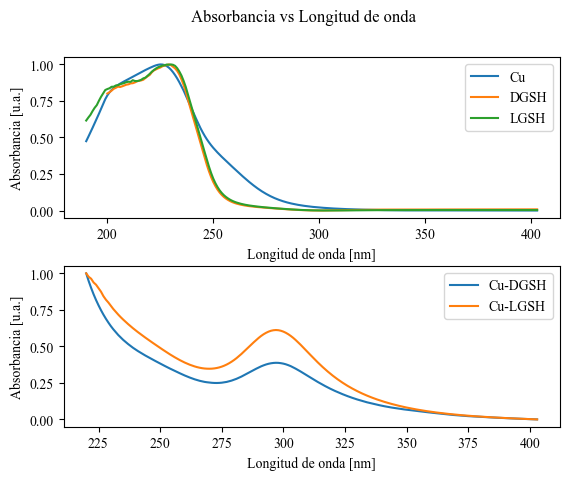

In [109]:
fig, axs = plt.subplot_mosaic([['1'], ['2']])
fig.suptitle('Absorbancia vs Longitud de onda')

axs['1'].plot(abs_dict['Cu'][0], abs_dict['Cu'][1], label='Cu')
axs['1'].plot(abs_dict['DGSH'][0], abs_dict['DGSH'][1], label='DGSH')
axs['1'].plot(abs_dict['LGSH'][0], abs_dict['LGSH'][1], label='LGSH')

axs['2'].plot(abs_dict['CuDGSH'][0], abs_dict['CuDGSH'][1], label='Cu-DGSH')
axs['2'].plot(abs_dict['CuLGSH'][0], abs_dict['CuLGSH'][1], label='Cu-LGSH')

for ax_name in axs:
    axs[ax_name].set(xlabel='Longitud de onda [nm]', ylabel='Absorbancia [u.a.]')
    axs[ax_name].legend()
plt.subplots_adjust(hspace=0.3)

plt.savefig('NPS_aborbance.png', dpi=300)

In [82]:
def normalize(data, background):
    wl, ell_data = data['Wavelength (nm)'], data['Ellipticity']
    ell_background = background['Ellipticity']
    #ell_data = ell_data 
    #ell_data = (ell_data - np.min(ell_data)) / (np.max(ell_data) - np.min(ell_data))
    return wl, ell_data

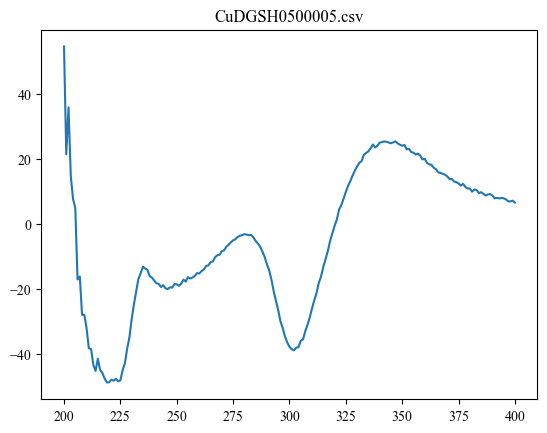

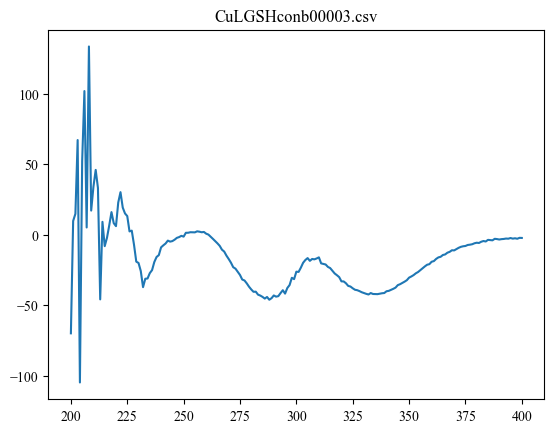

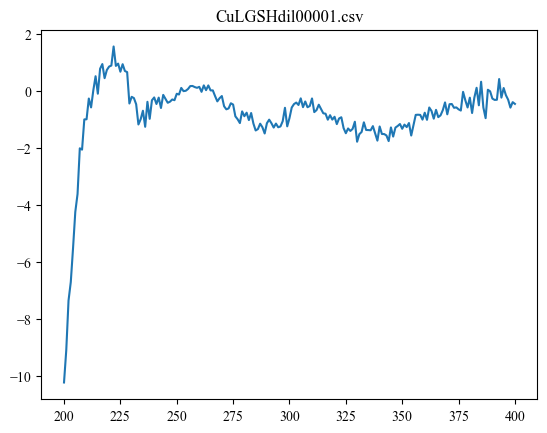

In [106]:
dirname = './CD'
listdir = os.listdir(dirname)

background = pd.read_csv(os.path.join(dirname, 'agua00000.csv'), skiprows=200, names=['Wavelength (nm)', 'Ellipticity'])[:201]
CD_dict = dict()

for file in listdir:
    if 'agua' in file:
        continue
    data = pd.read_csv(os.path.join(dirname, file), skiprows=200, names=['Wavelength (nm)', 'Ellipticity'])[:201]
    
    wl, ell = data['Wavelength (nm)'], data['Ellipticity'] - background['Ellipticity']

    fig, ax = plt.subplots()

    ax.plot(wl, ell)
    ax.set_title(file)

    CD_dict[file.replace('.csv', '')] = (wl, ell)

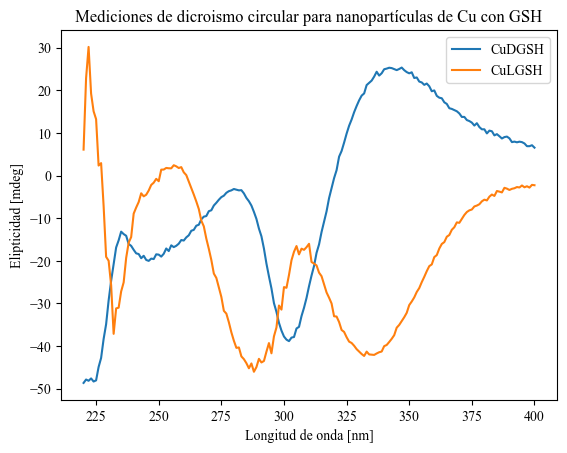

In [112]:
fig, ax = plt.subplots()

ax.plot(CD_dict['CuDGSH0500005'][0][:-20], CD_dict['CuDGSH0500005'][1][:-20], label='CuDGSH')
ax.plot(CD_dict['CuLGSHconb00003'][0][:-20], CD_dict['CuLGSHconb00003'][1][:-20], label='CuLGSH')

ax.set(xlabel='Longitud de onda [nm]', ylabel='Elipticidad [mdeg]', title='Mediciones de dicroismo circular para nanopartículas de Cu con GSH')
ax.legend()
plt.savefig('CD.png', dpi=200)